In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"

import tensorflow.compat.v1 as tf

tf.config.set_soft_device_placement(True)
# tf.debugging.set_log_device_placement(True)
# from sklearn.metrics import confusion_matrix
import numpy as np
# from scipy.io import loadmat
# from functools import reduce
# from scipy import signal
import pandas as pd
# from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from tensorflow import keras as K
from tensorflow.keras.layers import Add, Dense, Activation, Flatten, concatenate, Input, Dropout, LSTM, Conv2D, MaxPooling2D, Conv1D, MaxPooling1D, BatchNormalization, PReLU, ELU, ReLU
from tensorflow.keras.models import Sequential, Model, load_model
import matplotlib.pyplot as plt
# import datetime
# get_ipython().run_line_magic('load_ext', 'tensorboard')
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
# get_ipython().run_line_magic('matplotlib', 'inline')
# from collections import Counter 
np_load_old = np.load
# from tensorflow.keras.utils import plot_model
from tensorflow.keras.initializers import glorot_uniform
# modify the default parameters of np.load
np.load = lambda *a,**k: np_load_old(*a, allow_pickle=True, **k)
np.random.seed(42)
tf.set_random_seed(42)
from sklearn.metrics import classification_report
import argparse
import h5py
from sklearn.metrics import confusion_matrix
import itertools
import math

I0000 00:00:1773955347.583873  172874 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)
    plt.figure(figsize=(15,10))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=36)
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, fontsize=30)
    plt.yticks(tick_marks, classes, fontsize=30)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black", fontsize=28)

    plt.tight_layout()
    plt.ylabel('True label', fontsize=30)
    plt.xlabel('Predicted label', fontsize=30)

## Load in data

In [3]:
# load new train, validation, and test datasets
loadPath = '/home/sz4544/EEG-motor-imagery-main/project/'
os.makedirs(os.path.join(loadPath, "models"), exist_ok=True)
bestModel = '/home/sz4544/EEG-motor-imagery-main/project/models/baseline_full_dataset_2CNN.keras'

f_train = h5py.File(os.path.join(loadPath, "train12720_raw_EEG.h5"), "r")
tr_data = f_train['data'][:]
ytr = f_train['tasks'][:]
tr_subjects = f_train['subjects'][:]

f_valid = h5py.File(os.path.join(loadPath, "valid2544_raw_EEG.h5"), "r")
val_data = f_valid['data'][:]
yval = f_valid['tasks'][:]
val_subjects = f_valid['subjects'][:]

f_test = h5py.File(os.path.join(loadPath, "test2544_raw_EEG.h5"), "r")
ts_data = f_test['data'][:]
yts = f_test['tasks'][:]
ts_subjects = f_test['subjects'][:]

## Normalization

In [4]:
# flatten and reshape data
xtr_s_flattened = np.squeeze(tr_data).ravel().reshape((-1, 64))
xval_s_flattened = np.squeeze(val_data).ravel().reshape((-1, 64))
xts_s_flattened = np.squeeze(ts_data).ravel().reshape((-1, 64))
print(xtr_s_flattened.shape)
print(xval_s_flattened.shape)
print(xts_s_flattened.shape)

# normalize data
scaler = StandardScaler()
Ztr_temp = scaler.fit_transform(xtr_s_flattened)
Zval_temp = scaler.transform(xval_s_flattened)
Zts_temp = scaler.transform(xts_s_flattened)

# flatten and reshape data back
Ztr = np.squeeze(Ztr_temp).ravel().reshape((-1, 640, 64))
Zval = np.squeeze(Zval_temp).ravel().reshape((-1, 640, 64))
Zts = np.squeeze(Zts_temp).ravel().reshape((-1, 640, 64))
print(Ztr.shape)
print(Zval.shape)
print(Zts.shape)

(8140800, 64)
(1628160, 64)
(1628160, 64)
(12720, 640, 64)
(2544, 640, 64)
(2544, 640, 64)


In [5]:
x_train = Ztr[..., np.newaxis].astype(np.float32)
x_valid = Zval[..., np.newaxis].astype(np.float32)
x_test = Zts[..., np.newaxis].astype(np.float32)
y_train = pd.get_dummies(ytr).values.astype(np.float32)
y_valid = pd.get_dummies(yval).values.astype(np.float32)
y_test = pd.get_dummies(yts).values.astype(np.float32)

print("tr_data shape:", tr_data.shape)
print("val_data shape:", val_data.shape)
print("ts_data shape:", ts_data.shape)

print("x_train shape:", x_train.shape)
print("x_valid shape:", x_valid.shape)
print("x_test shape:", x_test.shape)

print("y_train shape:", y_train.shape)
print("y_valid shape:", y_valid.shape)
print("y_test shape:", y_test.shape)

tr_data shape: (12720, 640, 64)
val_data shape: (2544, 640, 64)
ts_data shape: (2544, 640, 64)
x_train shape: (12720, 640, 64, 1)
x_valid shape: (2544, 640, 64, 1)
x_test shape: (2544, 640, 64, 1)
y_train shape: (12720, 4)
y_valid shape: (2544, 4)
y_test shape: (2544, 4)


## Model architecture

In [6]:
class EEGSequence(K.utils.Sequence):
    def __init__(self, x, y, batch_size=32, shuffle=True):
        self.x = x
        self.y = y
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.x))
        self.on_epoch_end()

    def __len__(self):
        return math.ceil(len(self.x) / self.batch_size)

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_x = self.x[batch_idx]
        batch_y = self.y[batch_idx]
        return batch_x, batch_y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)



train_seq = EEGSequence(x_train, y_train, batch_size=32, shuffle=True)
valid_seq = EEGSequence(x_valid, y_valid, batch_size=32, shuffle=False)
test_seq  = EEGSequence(x_test, y_test, batch_size=32, shuffle=False)

In [7]:
nodes = 640
inputs = Input(shape=(nodes, 64, 1))

conv1 = Conv2D(8, (15,9), strides=(2,1), kernel_initializer=glorot_uniform(seed=42))(inputs)
batch1 = BatchNormalization()(conv1)
prelu1 = PReLU()(batch1)
maxpool1 = MaxPooling2D((2,2))(prelu1)

conv2 = Conv2D(16, (15,9), strides=(2,1), kernel_initializer=glorot_uniform(seed=42))(maxpool1)
batch2 = BatchNormalization()(conv2)
prelu2 = PReLU()(batch2)

flat = Flatten()(prelu2)
dense1 = Dense(16, activation='sigmoid', kernel_initializer=glorot_uniform(seed=42))(flat)
drop1 = Dropout(0.2)(dense1)
predictions = Dense(4, activation='softmax', kernel_initializer=glorot_uniform(seed=42))(drop1)

model = Model(inputs=inputs, outputs=predictions)
print(model.summary())

opt_adam = K.optimizers.Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.999, epsilon=1e-08)
model.compile(loss='categorical_crossentropy', optimizer=opt_adam, metrics=['categorical_accuracy'])

I0000 00:00:1773955354.221738  172874 gpu_process_state.cc:208] Using CUDA malloc Async allocator for GPU: 0
I0000 00:00:1773955354.221999  172874 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 734 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:41:00.0, compute capability: 8.9


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 640, 64, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 313, 56, 8)     │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 313, 56, 8)     │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu (PReLU)                 │ (None, 313, 56, 8)     │       140,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 156, 28, 8)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 71, 20, 16)     │        17,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 71, 20, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu_1 (PReLU)               │ (None, 71, 20, 16)     │        22,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 22720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │       363,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,028 (2.08 MB)

 Trainable params: 544,980 (2.08 MB)

 Non-trainable params: 48 (192.00 B)

None


In [8]:


es = EarlyStopping(monitor='val_categorical_accuracy', mode='max', verbose=1, patience=30)
mc = ModelCheckpoint(bestModel, monitor='val_categorical_accuracy', mode='max', verbose=1, save_best_only=True)

In [9]:
history = model.fit(
    train_seq,
    epochs=300,
    verbose=1,
    validation_data=valid_seq,
    callbacks=[es, mc]
)

Epoch 1/300


/home/sz4544/miniconda3/envs/eeg_cnn/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1773955354.815843  172874 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1773955355.659249  173150 service.cc:153] XLA service 0x7265d8037540 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773955355.659270  173150 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4090, Compute Capability 8.9 (Driver: 12.4.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.8.0)
I0000 00:00:1773955355.709394  173150 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPROD

 19/398 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - categorical_accuracy: 0.2396 - loss: 1.4867

I0000 00:00:1773955360.045493  173150 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


315/398 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - categorical_accuracy: 0.2739 - loss: 1.4058

I0000 00:00:1773955362.519337  173151 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2994__.41


395/398 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - categorical_accuracy: 0.2785 - loss: 1.4003
Epoch 1: val_categorical_accuracy improved from None to 0.33962, saving model to /home/sz4544/EEG-motor-imagery-main/project/models/baseline_full_dataset_2CNN.keras
398/398 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - categorical_accuracy: 0.3013 - loss: 1.3751 - val_categorical_accuracy: 0.3396 - val_loss: 1.3579
Epoch 2/300
392/398 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - categorical_accuracy: 0.3637 - loss: 1.3168
Epoch 2: val_categorical_accuracy improved from 0.33962 to 0.37972, saving model to /home/sz4544/EEG-motor-imagery-main/project/models/baseline_full_dataset_2CNN.keras
398/398 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - categorical_accuracy: 0.3729 - loss: 1.3050 - val_categorical_accuracy: 0.3797 - val_loss: 1.2969
Epoch 3/300
394/398 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - categorical_accuracy: 0.4139 - loss: 1.2488
Epoch 3: val_categorical_accuracy improved from 0.37972 to 0.38758, saving model to /home/sz4544/

## Model testing

In [10]:
best_model = tf.keras.models.load_model(bestModel)
yhat = np.argmax(best_model.predict(test_seq), axis=1)
ytrue = np.argmax(y_test, axis=1)
print('test acc: {:.2f}%'.format(np.sum(yhat == ytrue) / yts.shape[0] * 100))

80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
test acc: 44.26%


In [11]:
target_names = ['open one hand', 'imagine open one hand', 'open both hands/feet', 'imagine open both hands/feet']
print(classification_report(ytrue, yhat, target_names=target_names, digits=4))

                              precision    recall  f1-score   support

               open one hand     0.4432    0.3742    0.4058       636
       imagine open one hand     0.4209    0.4686    0.4435       636
        open both hands/feet     0.4465    0.6164    0.5178       636
imagine open both hands/feet     0.4703    0.3113    0.3746       636

                    accuracy                         0.4426      2544
                   macro avg     0.4452    0.4426    0.4354      2544
                weighted avg     0.4452    0.4426    0.4354      2544



In [12]:
cm = confusion_matrix(ytrue, yhat)
cm

array([[238, 196, 153,  49],
       [154, 298, 100,  84],
       [ 72,  82, 392,  90],
       [ 73, 132, 233, 198]])

Normalized confusion matrix
[[0.37421384 0.3081761  0.24056604 0.07704403]
 [0.24213836 0.46855346 0.1572327  0.13207547]
 [0.11320755 0.12893082 0.6163522  0.14150943]
 [0.11477987 0.20754717 0.3663522  0.31132075]]


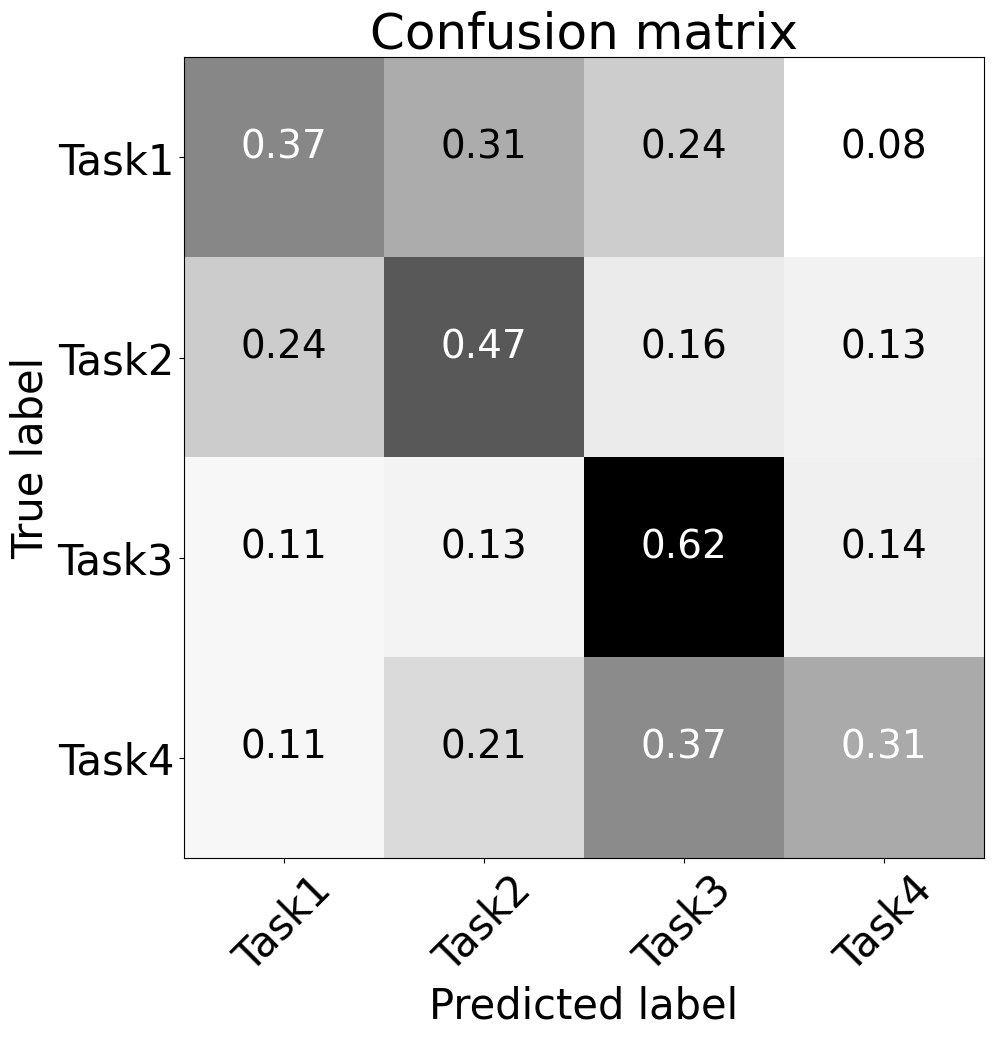

In [13]:
plot_confusion_matrix(cm, ['Task1', 'Task2', 'Task3', 'Task4'], normalize=True, title='Confusion matrix', cmap=plt.cm.Greys)